In [1]:
import os
os.chdir('../')

In [2]:
!ls logs/sd/amed_ari_edm

s2


2025-11-27 19:10:44.689430: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-27 19:10:44.719304: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/scpark/miniconda3/envs/sana/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warn

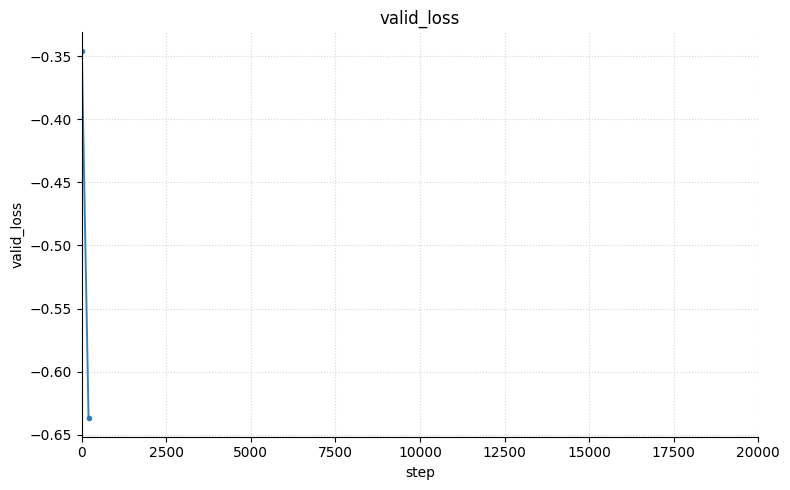

In [3]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ['logs/sd/amed_ari_edm/s2',
            ]
TAGS = ['valid_loss']

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r).name)
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if len(metrics[t])>1: ax.legend(frameon=False)
        plt.xlim([0, 20*1000]); plt.tight_layout(); plt.show()


In [4]:
print('done')

done
